# Notebook 09: Concept Drift Detection and Behaviour Adaptation

## Objective

Detect changes in user/device behavioural patterns over time and
adapt baseline profiles to reduce false positives caused by legitimate
behaviour changes.

## Workflow

Historical Behaviour Data
        ↓
Baseline Profile Creation
        ↓
New Behaviour Window
        ↓
Drift Detection (PSI + KS Test)
        ↓
Drift Score Calculation
        ↓
Behaviour Profile Update
        ↓
Drift Reports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

In [2]:
os.makedirs("reports/drift",exist_ok=True)

print("Drift report directory created")

Drift report directory created


In [3]:
features = pd.read_csv("/content/deeptrace_features_FINAL.csv")

processed = pd.read_csv("/content/deeptrace_processed.csv")

print("Features:", features.shape)
print("Processed:", processed.shape)

Features: (239480, 49)
Processed: (239480, 51)


In [4]:
split_index = int(len(features)*0.7)


baseline_data = features.iloc[:split_index]


current_data = features.iloc[split_index:]


print(
    baseline_data.shape,
    current_data.shape
)

(167636, 49) (71844, 49)


In [5]:
def calculate_psi(expected, actual, buckets=10):

    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.linspace(
        0,
        100,
        buckets + 1
    )

    breakpoints = np.percentile(
        expected,
        breakpoints
    )

    expected_counts = np.histogram(
        expected,
        bins=breakpoints
    )[0]

    actual_counts = np.histogram(
        actual,
        bins=breakpoints
    )[0]

    expected_ratio = expected_counts / len(expected)
    actual_ratio = actual_counts / len(actual)

    expected_ratio = np.where(
        expected_ratio == 0,
        0.0001,
        expected_ratio
    )

    actual_ratio = np.where(
        actual_ratio == 0,
        0.0001,
        actual_ratio
    )

    psi = np.sum(
        (actual_ratio - expected_ratio)
        *
        np.log(actual_ratio / expected_ratio)
    )

    return psi

In [6]:
drift_results = []

for feature in features.columns:

    baseline_feature = baseline_data[feature]
    current_feature = current_data[feature]

    # KS Test
    ks_stat, p_value = ks_2samp(
        baseline_feature,
        current_feature
    )

    # PSI
    psi_score = calculate_psi(
        baseline_feature,
        current_feature
    )

    if psi_score < 0.1:
        status = "Stable"

    elif psi_score < 0.25:
        status = "Warning"

    else:
        status = "Drift Detected"


    drift_results.append({

        "Feature": feature,
        "KS Statistic": ks_stat,
        "P Value": p_value,
        "PSI Score": psi_score,
        "Status": status

    })


drift_df = pd.DataFrame(drift_results)


drift_df.head()

,Feature,KS Statistic,P Value,PSI Score,Status
0,department,0.078080,4.077377e-267,0.108691,Warning
1,role,0.072765,5.286422e-232,0.169809,Warning
2,office_location,0.107803,0.000000e+00,0.096045,Stable
3,device,0.022074,1.019772e-21,0.011252,Stable
4,network_type,0.007580,6.152451e-03,0.000273,Stable


In [7]:
drift_summary = drift_df["Status"].value_counts()

drift_summary

,count
Status,
Stable,47
Warning,2


In [8]:
overall_drift_score = drift_df["PSI Score"].mean()

print(
    "Overall Drift Score:",
    round(overall_drift_score,4)
)

Overall Drift Score: 0.0125


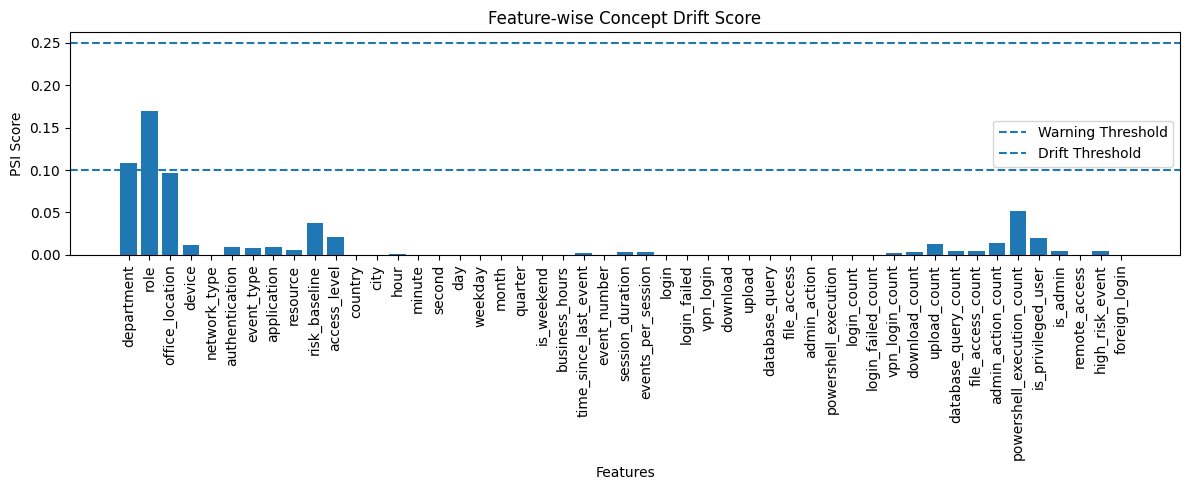

In [9]:
plt.figure(figsize=(12,5))

plt.bar(
    drift_df["Feature"],
    drift_df["PSI Score"]
)

plt.xticks(
    rotation=90
)

plt.axhline(
    y=0.1,
    linestyle="--",
    label="Warning Threshold"
)

plt.axhline(
    y=0.25,
    linestyle="--",
    label="Drift Threshold"
)

plt.title("Feature-wise Concept Drift Score")
plt.xlabel("Features")
plt.ylabel("PSI Score")

plt.legend()

plt.tight_layout()

plt.savefig(
    "reports/drift/drift_distribution.png",
    dpi=300
)

plt.show()

In [10]:
drift_df.to_csv(
    "reports/drift/concept_drift_report.csv",
    index=False
)

print("Concept drift report saved")

Concept drift report saved


In [11]:
overall_score = drift_df["PSI Score"].mean()

if overall_score < 0.1:
    system_status = "Stable"

elif overall_score < 0.25:
    system_status = "Moderate Drift"

else:
    system_status = "Significant Drift"


summary = f"""
DeepTrace Concept Drift Analysis

Overall Drift Score:
{overall_score:.4f}

System Status:
{system_status}


Feature Summary:

Stable Features:
{(drift_df.Status == 'Stable').sum()}

Warning Features:
{(drift_df.Status == 'Warning').sum()}

Drift Detected Features:
{(drift_df.Status == 'Drift Detected').sum()}


Observed Changes:

{drift_df[drift_df.Status != 'Stable'][['Feature','PSI Score','Status']].to_string(index=False)}

"""


with open(
    "reports/drift/drift_summary.txt",
    "w"
) as f:
    f.write(summary)


print(summary)


DeepTrace Concept Drift Analysis

Overall Drift Score:
0.0125

System Status:
Stable


Feature Summary:

Stable Features:
47

Warning Features:
2

Drift Detected Features:
0


Observed Changes:

   Feature  PSI Score  Status
department   0.108691 Warning
      role   0.169809 Warning




In [12]:
baseline_profile = baseline_data.mean()

current_profile = current_data.mean()


profile_update = (
    0.8 * baseline_profile
    +
    0.2 * current_profile
)


adaptation_df = pd.DataFrame({
    "Feature": baseline_profile.index,
    "Old_Baseline": baseline_profile.values,
    "Current_Behaviour": current_profile.values,
    "Updated_Profile": profile_update.values
})


adaptation_df.head()

,Feature,Old_Baseline,Current_Behaviour,Updated_Profile
0,department,0.471063,0.475544,0.471959
1,role,0.468994,0.503075,0.475810
2,office_location,0.506223,0.463393,0.497657
3,device,0.725208,0.733770,0.726921
4,network_type,0.111847,0.111151,0.111707


## Behaviour Profile Adaptation

When legitimate behaviour changes are detected, DeepTrace updates the
baseline behaviour profile gradually instead of permanently marking the
entity as anomalous.

Updated Profile:

New Profile =
0.8 × Previous Profile +
0.2 × Current Behaviour

In [13]:
os.makedirs(
    "models/adaptive_profiles",
    exist_ok=True
)


adaptation_df.to_csv(
    "models/adaptive_profiles/updated_behavior_profile.csv",
    index=False
)


print("Adaptive behaviour profile saved")

Adaptive behaviour profile saved


In [14]:
adapted_features = drift_df[
    drift_df["Status"] == "Warning"
]["Feature"].tolist()


summary = f"""

DeepTrace Behaviour Adaptation Report

Features Updated:
{len(adapted_features)}

Updated Features:
{adapted_features}


Adaptation Strategy:

New Profile =
0.8 * Historical Behaviour
+
0.2 * Current Behaviour


Purpose:

Reduce false positives caused by legitimate behavioural changes.

"""


with open(
    "reports/drift/adaptation_summary.txt",
    "w"
) as f:
    f.write(summary)


print(summary)



DeepTrace Behaviour Adaptation Report

Features Updated:
2

Updated Features:
['department', 'role']


Adaptation Strategy:

New Profile =
0.8 * Historical Behaviour
+
0.2 * Current Behaviour


Purpose:

Reduce false positives caused by legitimate behavioural changes.




# Conclusion

DeepTrace implements adaptive concept drift detection to monitor
changes in user and device behaviour over time.

The system combines statistical drift detection using PSI and
Kolmogorov-Smirnov tests with adaptive baseline updating.

Detected behavioural changes are gradually incorporated into updated
profiles using weighted adaptation, reducing false positives caused by
legitimate changes while maintaining threat detection capability.